## Lnt Camp 2026 final project

### A. Problem Statement and Objective
This project analyses the Global Superstore dataset to help the business
understand what drives sales and profitability across its global operations.

#### For the modeling tasks:
1. Regression: Predicting future sales to support revenue forecasting
2. Classification: Predict whether a order item is profitable or not, so it can catch the error before it happen

### B. Database Connection & Data Loading
Initialized the required libraries and connect the data from database using sqlite3

In [39]:
# Declaring the library need to support this modeling tasks
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Connect the notebook to the database (superstore)
conn = sqlite3.connect("database.sqlite")

Joined all the tables in the database for better analysis

In [40]:
query = """
SELECT
    oi.row_id,
    oi.order_key,
    oi.product_id,
    oi.discount,
    oi.quantity,
    oi.sales,
    oi.profit,
    oi.shipping_cost,
    oi.year,
    oi.week_num,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.order_priority,
    o.customer_id,
    o.location_id,
    c.customer_name,
    c.segment,
    p.category,
    p.sub_category,
    p.product_name,
    l.city,
    l.state,
    l.country,
    l.region,
    l.market
FROM order_items oi
JOIN orders o ON oi.order_key = o.order_key
JOIN dim_customers c ON o.customer_id = c.customer_id
JOIN dim_products p ON oi.product_id = p.product_id
JOIN dim_locations l ON o.location_id = l.location_id
"""

df = pd.read_sql_query(query, conn)

The result has 51,290 rows — matching the row count of `order_items`,
confirming the joins did not duplicate or drop any records.

In [41]:
print(df.shape)
df.head()

(51290, 26)


,row_id,order_key,product_id,discount,quantity,sales,profit,shipping_cost,year,week_num,...,customer_name,segment,category,sub_category,product_name,city,state,country,region,market
0,1,MX-2014-143658_SC-205753,OFF-LA-10002782,0.0,3,13.0,4.56,1.033,2014,40,...,Sonia Cooley,Consumer,Office Supplies,Labels,"Hon File Folder Labels, Adjustable",Mexico City,Distrito Federal,Mexico,North,LATAM
1,2,MX-2012-155047_KW-165703,FUR-FU-10004015,0.0,8,252.0,90.72,13.449,2012,42,...,Kelly Williams,Consumer,Furniture,Furnishings,"Tenex Clock, Durable",Dos Quebradas,Risaralda,Colombia,South,LATAM
2,3,MX-2012-155047_KW-165703,FUR-BO-10002352,0.0,2,193.0,54.08,9.627,2012,42,...,Kelly Williams,Consumer,Furniture,Bookcases,"Ikea 3-Shelf Cabinet, Mobile",Dos Quebradas,Risaralda,Colombia,South,LATAM
3,4,MX-2012-155047_KW-165703,OFF-BI-10004428,0.0,4,35.0,4.96,1.371,2012,42,...,Kelly Williams,Consumer,Office Supplies,Binders,"Cardinal Binder, Clear",Dos Quebradas,Risaralda,Colombia,South,LATAM
4,5,MX-2012-155047_KW-165703,OFF-AR-10004594,0.0,2,72.0,11.44,3.787,2012,42,...,Kelly Williams,Consumer,Office Supplies,Art,"Sanford Canvas, Water Color",Dos Quebradas,Risaralda,Colombia,South,LATAM


`order_date` and `ship_date` load as text from SQLite, so they are converted to datetime objects for date calculation.

In [42]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

### C. Feature Engineering
there are 3 new columns that use for counting and classify the `order_items` pofitable and how the effect of the shipping cost to the profit margin. For the explaination as follows:
1. `delivery_duration` = counting the days between the `order_date` and the `ship_date`
2. `is_profitable` = determine whether the profit be negative which represent as 0 or the profit is positive represent as 1
3. `profit_margin` = counting how much each dollar in sales become profit

In [43]:
df['delivery_duration'] = (df['ship_date'] - df['order_date']).dt.days
df['is_profitable'] = (df['profit'] > 0).astype(int)
df['profit_margin'] = df['profit'] / df['sales']

df[['delivery_duration', 'is_profitable', 'profit_margin']].head()

,delivery_duration,is_profitable,profit_margin
0,4,1,0.350769
1,5,1,0.360000
2,5,1,0.280207
3,5,1,0.141714
4,5,1,0.158889


In [44]:
df['is_profitable'].value_counts(normalize=True)

is_profitable
1    0.742406
0    0.257594
Name: proportion, dtype: float64

the profitable 'order_items' is 74.2% compare to the non-profitable 'order_items' about 25.8%

### D. Exploratory Data Analysis
This section will be the analysis based on database about superstore and will be summarize through the end. The data will be use to identify the characteristic of the data.

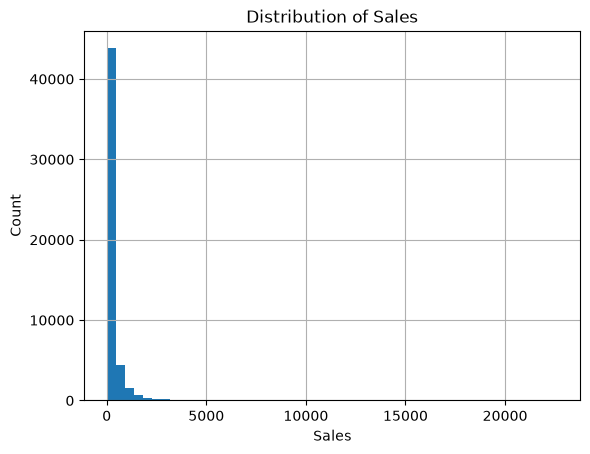

In [45]:
df['sales'].hist(bins=50)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Count')
plt.show()

Sales is heavily right-skewed: most order items are low-value, with a small number of
large orders pulling the distribution's tail far to the right. This suggests the business
relies on a broad base of small transactions rather than a few big ones.

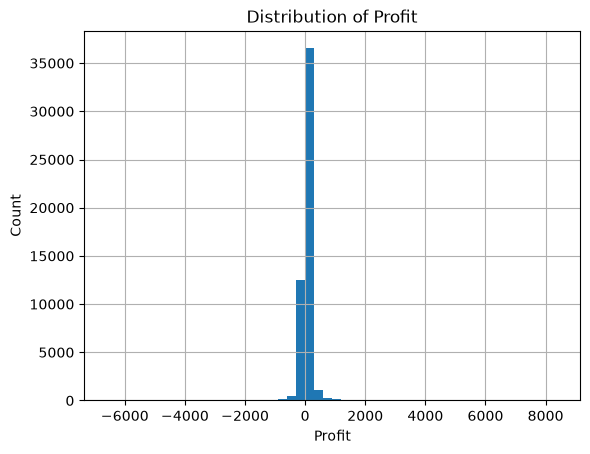

In [46]:
df['profit'].hist(bins=50)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Count')
plt.show()

The unclipped profit distribution is too bis to analyze therefore we need to clipped it

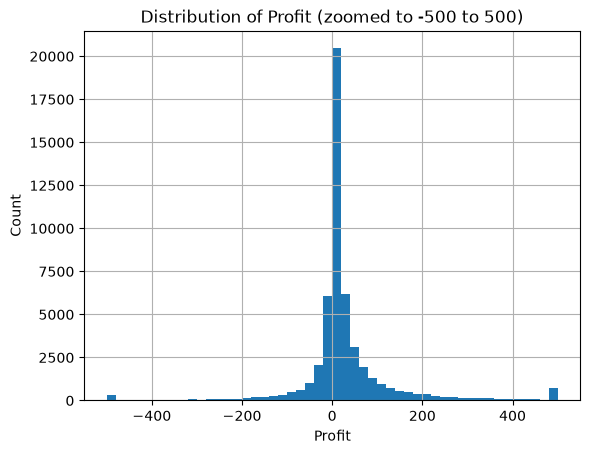

In [47]:
df['profit'].clip(-500, 500).hist(bins=50)
plt.title('Distribution of Profit (zoomed to -500 to 500)')
plt.xlabel('Profit')
plt.ylabel('Count')
plt.show()

In this clipped version we can take a look at the chart most of the `order_items` profit is break even by majority and some of the `order_items` also has a profitable and non-profitable far outside the chart

#### The next several histogram is for category and sub-category breakdown for better analysis about the sales and profit in each category

                     sales        profit
category                                
Technology       4744691.0  663778.73318
Furniture        4110884.0  285204.72380
Office Supplies  3787330.0  518473.83430


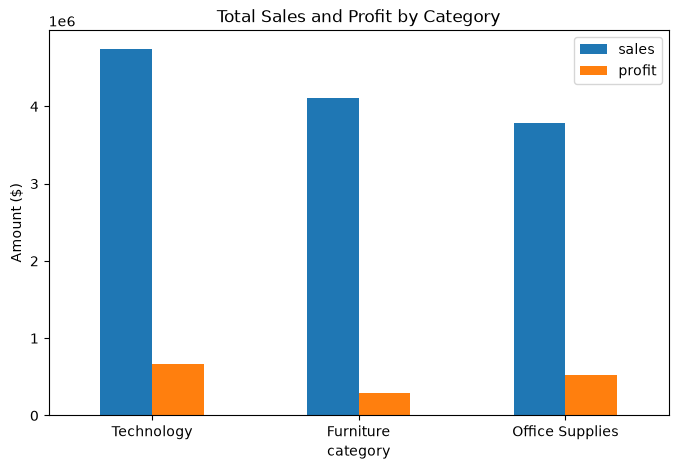

In [48]:
category_summary = df.groupby('category')[['sales', 'profit']].sum().sort_values('sales', ascending=False)
print(category_summary)

category_summary.plot(kind='bar', figsize=(8,5))
plt.title('Total Sales and Profit by Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.show()

Look at the chart we can see that the Technology category has the most sales and also has the most profit. But for the best profit margin is in office supplies.

                  sales        profit
sub_category                         
Tables         757034.0  -64083.38870
Fasteners       83254.0   11525.42410
Labels          73413.0   15008.85600
Supplies       243090.0   22583.26310
Envelopes      170926.0   29601.11630
Furnishings    385609.0   46967.42550
Art            372163.0   57953.91090
Machines       779071.0   58867.87300
Paper          244307.0   59207.68270
Binders        461972.0   72451.50200
Storage       1127124.0  108461.48980
Accessories    749307.0  129626.30620
Chairs        1501682.0  140396.26750
Appliances    1011081.0  141680.58940
Bookcases     1466559.0  161924.41950
Phones        1706874.0  216717.00580
Copiers       1509439.0  258567.54818


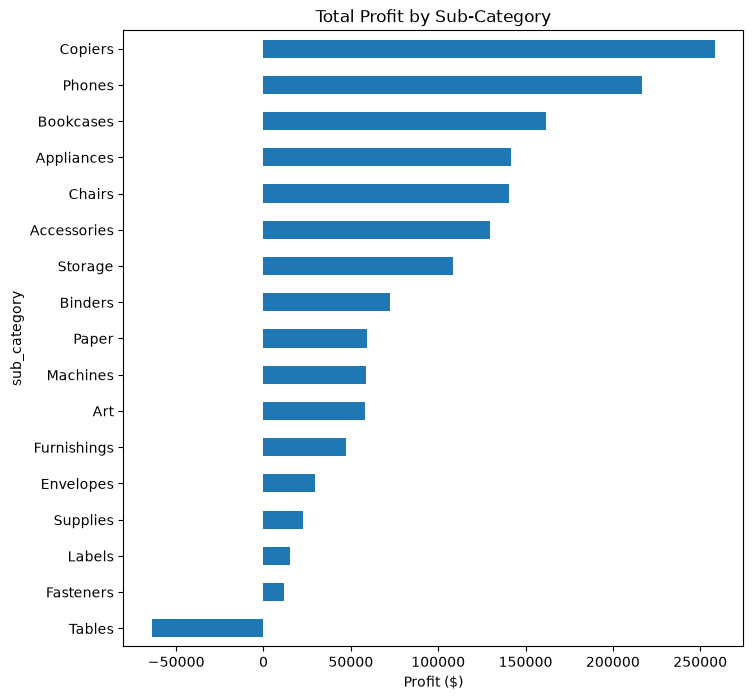

In [49]:
subcat_summary = df.groupby('sub_category')[['sales', 'profit']].sum().sort_values('profit')
print(subcat_summary)

subcat_summary['profit'].plot(kind='barh', figsize=(8,8))
plt.title('Total Profit by Sub-Category')
plt.xlabel('Profit ($)')
plt.show()

Breaking down total profit by sub-category reveals that **Tables** is the only 
sub-category with negative total profit, despite having a meaningful volume of sales. 
This suggests Tables are being sold at a loss overall — likely driven by heavy 
discounting or high shipping costs relative to price. This is the clearest actionable 
insight from the category-level analysis.

          discount    profit
discount  1.000000 -0.680711
profit   -0.680711  1.000000


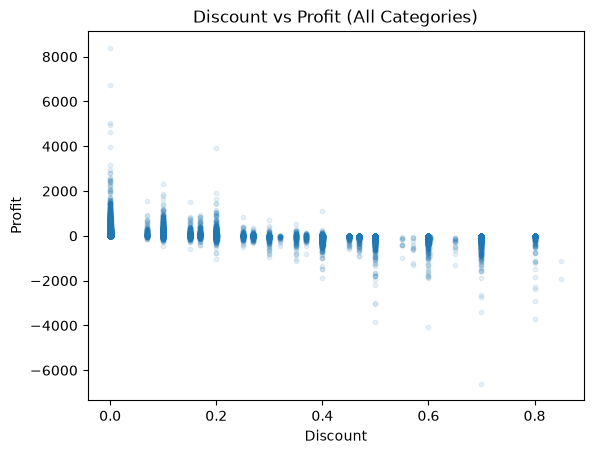

In [50]:
tables_df = df[df['sub_category'] == 'Tables']
print(tables_df[['discount', 'profit']].corr())

plt.scatter(df['discount'], df['profit'], alpha=0.1, s=10)
plt.title('Discount vs Profit (All Categories)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

The scatter shows that the items without the discount has the profitable way then the discounted items. The items that discounted above ~40% are almost entirely unprofitable. 

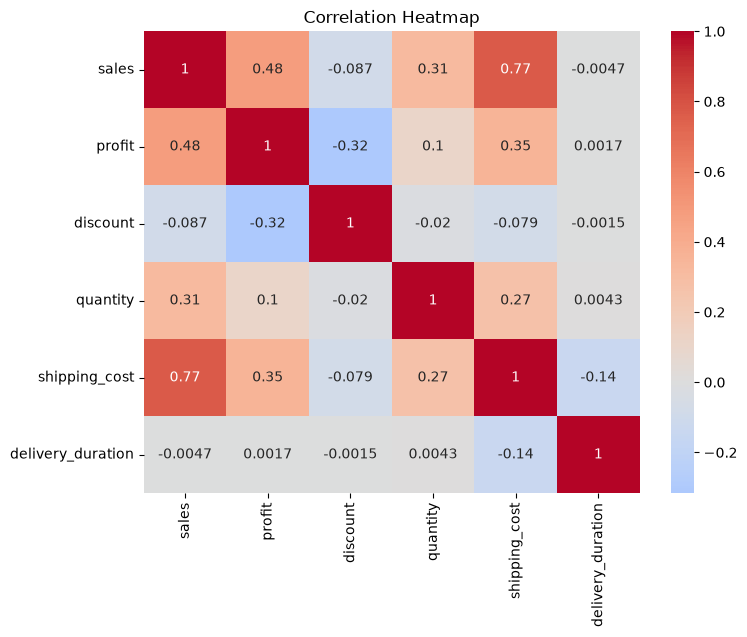

In [51]:
numeric_cols = ['sales', 'profit', 'discount', 'quantity', 'shipping_cost', 'delivery_duration']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

### EDA Summary

Key findings from exploratory analysis:
- Sales and profit are both right-skewed, with a small number of large orders driving 
  the tail.
- The classification target is moderately imbalanced: 74.2% profitable vs 25.8% not.
- **Tables** is the only sub-category with negative total profit.
- Discount is negatively associated with profit — heavier discounts strongly correlate 
  with losses.

These insights directly inform the modelling approach: discount and category-related 
features are expected to be strong predictors for both the regression and classification 
tasks.

### D. Data Pre-processing
In this section it will be a completion of the previous feature engineering because it already be done.

Firstly we drop all the table that we don't need and tables that not have numerical data because we need numerical data to analyze or make a model of it

In [52]:
model_df = df.drop(columns=[
    'row_id', 'order_key', 'product_id', 'customer_id', 'customer_name',
    'product_name', 'order_date', 'ship_date', 'city', 'state', 'country'
])

model_df.columns

Index(['discount', 'quantity', 'sales', 'profit', 'shipping_cost', 'year',
       'week_num', 'ship_mode', 'order_priority', 'location_id', 'segment',
       'category', 'sub_category', 'region', 'market', 'delivery_duration',
       'is_profitable', 'profit_margin'],
      dtype='str')

In [53]:
categorical_cols = ['ship_mode', 'order_priority', 'segment', 'category', 'sub_category', 'region', 'market']

model_df_encoded = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

print(model_df_encoded.shape)
model_df_encoded.columns.tolist()

(51290, 55)


['discount',
 'quantity',
 'sales',
 'profit',
 'shipping_cost',
 'year',
 'week_num',
 'location_id',
 'delivery_duration',
 'is_profitable',
 'profit_margin',
 'ship_mode_Same Day',
 'ship_mode_Second Class',
 'ship_mode_Standard Class',
 'order_priority_High',
 'order_priority_Low',
 'order_priority_Medium',
 'segment_Corporate',
 'segment_Home Office',
 'category_Office Supplies',
 'category_Technology',
 'sub_category_Appliances',
 'sub_category_Art',
 'sub_category_Binders',
 'sub_category_Bookcases',
 'sub_category_Chairs',
 'sub_category_Copiers',
 'sub_category_Envelopes',
 'sub_category_Fasteners',
 'sub_category_Furnishings',
 'sub_category_Labels',
 'sub_category_Machines',
 'sub_category_Paper',
 'sub_category_Phones',
 'sub_category_Storage',
 'sub_category_Supplies',
 'sub_category_Tables',
 'region_Canada',
 'region_Caribbean',
 'region_Central',
 'region_Central Asia',
 'region_EMEA',
 'region_East',
 'region_North',
 'region_North Asia',
 'region_Oceania',
 'region_So

Categorical columns are one-hot encoded using `pd.get_dummies`, converting each category 
into binary indicator columns. `drop_first=True` avoids redundant columns, since one 
category can always be inferred from the others being zero

In [54]:
train_df, test_df = train_test_split(model_df_encoded, test_size=0.2, random_state=42)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (41032, 55)
Test shape: (10258, 55)


The dataset is split into 80-20 for test into 41032 and 10258 with 55 features after encoding

### E. Modelling 1 - Regression
Predicting `sales` for an order item using Linear Regression. Sales is chosen as the 
target because Section 3's EDA showed a strong right-skewed distribution driven by 
discount and category patterns, making it a meaningful and predictable business metric.

In [55]:
X_train_reg = train_df.drop(columns=['sales', 'profit', 'profit_margin', 'is_profitable'])
y_train_reg = train_df['sales']

X_test_reg = test_df.drop(columns=['sales', 'profit', 'profit_margin', 'is_profitable'])
y_test_reg = test_df['sales']

print(X_train_reg.shape, y_train_reg.shape)
print(X_test_reg.shape, y_test_reg.shape)

(41032, 51) (41032,)
(10258, 51) (10258,)


Linear Regression modelling is used, so it will be easy and simple to explain to a business audience

In [56]:
model_reg = LinearRegression()
model_reg.fit(X_train_reg, y_train_reg)

print("Model trained.")

Model trained.


In [57]:
y_pred_reg = model_reg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  116.89
RMSE: 256.86
R²:   0.7151


The model achieve the R² about 0.715 indicate that the model using 71.5% of the variation of the data. the MAE or Mean Absolute Error is about 116.89 this means that the model predictions likely of by $117, but the RMSE or Root Mean Square Error is about 256.86 where in this case is far more than MAE which means it has many outliers. Therefore we can conclude that this model is reliable in predicting typical order sales, but it likely to be wrong in predicting an unsual order sales